<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Load-Standard-Data-Science-Packages" data-toc-modified-id="Load-Standard-Data-Science-Packages-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Load Standard Data Science Packages</a></span></li><li><span><a href="#Load-&amp;-Visualize-Data" data-toc-modified-id="Load-&amp;-Visualize-Data-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Load &amp; Visualize Data</a></span><ul class="toc-item"><li><span><a href="#Pure-Amplification-Curves" data-toc-modified-id="Pure-Amplification-Curves-2.1"><span class="toc-item-num">2.1&nbsp;&nbsp;</span>Pure Amplification Curves</a></span></li><li><span><a href="#Pure-Melting-Curves" data-toc-modified-id="Pure-Melting-Curves-2.2"><span class="toc-item-num">2.2&nbsp;&nbsp;</span>Pure Melting Curves</a></span></li><li><span><a href="#Mixture-Amplification-Curves" data-toc-modified-id="Mixture-Amplification-Curves-2.3"><span class="toc-item-num">2.3&nbsp;&nbsp;</span>Mixture Amplification Curves</a></span></li><li><span><a href="#Mixture-Melting-Curves" data-toc-modified-id="Mixture-Melting-Curves-2.4"><span class="toc-item-num">2.4&nbsp;&nbsp;</span>Mixture Melting Curves</a></span></li></ul></li></ul></div>

# Load Standard Data Science Packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()
sns.set_style("whitegrid")
sns.set_style("ticks")

# Set suitable default colours for colorblind
import matplotlib as mpl
from cycler import cycler
from matplotlib.colors import to_hex
mpl.rcParams['axes.prop_cycle'] = cycler(color=[to_hex(i) for i in
                                                [(0,0.45,0.70),
                                                (0.9, 0.6, 0.0), 
                                                (0.0, 0.60, 0.50), 
                                                (0.8, 0.4, 0), 
                                                (0.35, 0.7, 0.9), 
                                                (0.8, 0.6, 0.7), 
                                                (0.5, 0.5, 0.5),
                                                (0.95, 0.9, 0.25)]])

#############################
# Import utility packages
#############################
from tqdm.auto import tqdm
from pathlib import Path
import dill as pickle
from collections import OrderedDict
from functools import reduce
import utilities as utils

#############################
# Set constants
#############################
DPI = 100 # This is the quality of figures

/Users/kautsarg/Library/CloudStorage/OneDrive-ImperialCollegeLondon/Final Project/3. Initial code/titan-signal-processing-main/venv_titan/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load & Visualize Data

## Pure Amplification Curves

In [2]:
qPCR_pure = pd.read_csv('Data/qPCR_Dataset_Pure.csv')
qPCR_pure.head()

,LoadedPanels,MeltLabels,Scaling,Conc,Cycle0,Cycle1,Cycle2,Cycle3,Cycle4,Cycle5,...,Cycle30,Cycle31,Cycle32,Cycle33,Cycle34,Cycle35,Cycle36,Cycle37,Cycle38,Cycle39
0,VIM,VIM,3.170058,1000000.0,-0.003309,-0.002386,0.000542,0.000648,0.000731,0.002804,...,2.418367,2.522085,2.612554,2.698740,2.775521,2.847920,2.917358,2.975949,3.034336,3.091613
1,VIM,VIM,3.185402,500000.0,-0.003791,-0.001600,0.000138,-0.000441,0.002338,0.002091,...,2.381360,2.491002,2.594423,2.685421,2.771973,2.845303,2.916192,2.983547,3.043709,3.093961
2,VIM,VIM,3.108354,100000.0,-0.000905,-0.000973,-0.000304,-0.000060,0.002015,-0.000481,...,2.053476,2.190912,2.319877,2.435982,2.544470,2.641278,2.730547,2.814077,2.889148,2.957316
3,VIM,VIM,2.975209,50000.0,-0.001656,-0.002201,-0.000422,0.000667,0.001260,0.001936,...,1.812400,1.965432,2.104128,2.231434,2.350091,2.457841,2.555830,2.641816,2.722089,2.793967
4,VIM,VIM,2.835439,10000.0,-0.000387,-0.000474,0.000412,-0.000527,0.000487,0.000672,...,1.427750,1.607046,1.773881,1.923613,2.062173,2.188772,2.303949,2.410356,2.505563,2.590896


In [11]:
qPCR_pure.shape

(48, 44)

In [3]:
qPCR_pure.LoadedPanels.unique()

array(['VIM', 'OXA', 'NDM', 'KPC'], dtype=object)

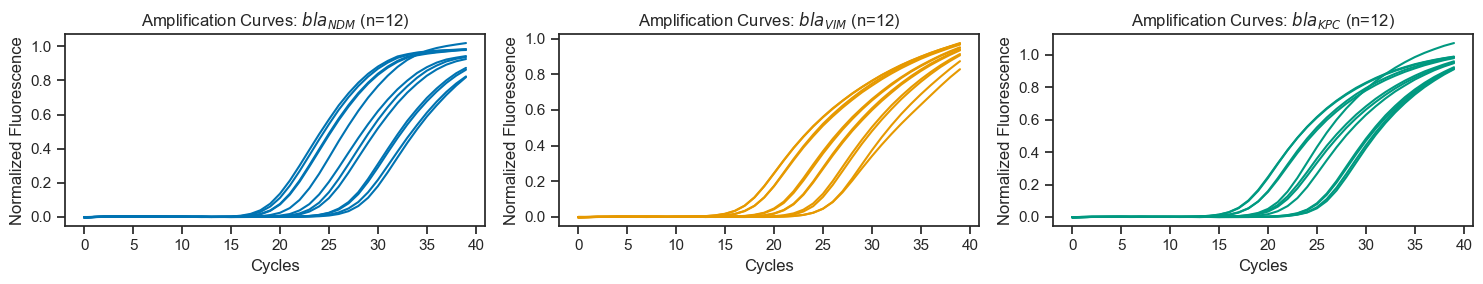

In [4]:
targets = ['NDM', 'VIM', 'KPC']
names = ['$bla_{NDM}$', '$bla_{VIM}$', '$bla_{KPC}$']
colors = ['C0', 'C1', 'C2']
data = utils.normalized(qPCR_pure)
data_type = 'AC'
xlabel = 'Cycles'
ylabel = 'Normalized Fluorescence'
title = 'Amplification Curves'

fig, ax = plt.subplots(1, len(targets), dpi=DPI, figsize=(15, 3))
for i, (target, name, color) in enumerate(zip(targets, names, colors)):
    
    utils.plot_curves(ax[i], data, target, name, color, data_type, xlabel, ylabel, title)
    
plt.tight_layout()
plt.show()

## Pure Melting Curves

In [5]:
qPCR_pure_melting = utils.interpolate_melting(pd.read_csv('Data/qPCR_Meltings_Pure.csv'))
qPCR_pure_melting.head()

,LoadedPanels,65.1846,65.1859,65.191,65.1916,65.1922,65.1928,65.1945,65.2079,65.2205,...,97.1015,97.1068,97.1084,97.1091,97.1183,97.1276,97.1302,97.1375,97.1387,97.1701
0,VIM,0.001010,0.001011,0.001013,0.001014,0.001015,0.001016,0.001017,0.001019,0.001020,...,0.000188,0.000188,0.000188,0.000188,0.000188,0.000188,0.000188,0.000188,0.000188,0.000188
1,VIM,0.001066,0.001067,0.001068,0.001069,0.001070,0.001071,0.001072,0.001073,0.001075,...,0.000168,0.000168,0.000168,0.000168,0.000168,0.000168,0.000168,0.000168,0.000168,0.000168
2,VIM,0.001227,0.001227,0.001228,0.001228,0.001229,0.001229,0.001230,0.001230,0.001231,...,0.000156,0.000156,0.000156,0.000156,0.000156,0.000156,0.000156,0.000156,0.000156,0.000156
3,VIM,0.001080,0.001081,0.001082,0.001083,0.001083,0.001084,0.001085,0.001086,0.001087,...,0.000144,0.000144,0.000144,0.000144,0.000144,0.000144,0.000144,0.000144,0.000144,0.000144
4,VIM,0.000943,0.000944,0.000945,0.000946,0.000947,0.000948,0.000949,0.000950,0.000951,...,0.000170,0.000170,0.000170,0.000170,0.000170,0.000170,0.000170,0.000170,0.000170,0.000170


In [28]:
qPCR_pure_melting.shape

(48, 7543)

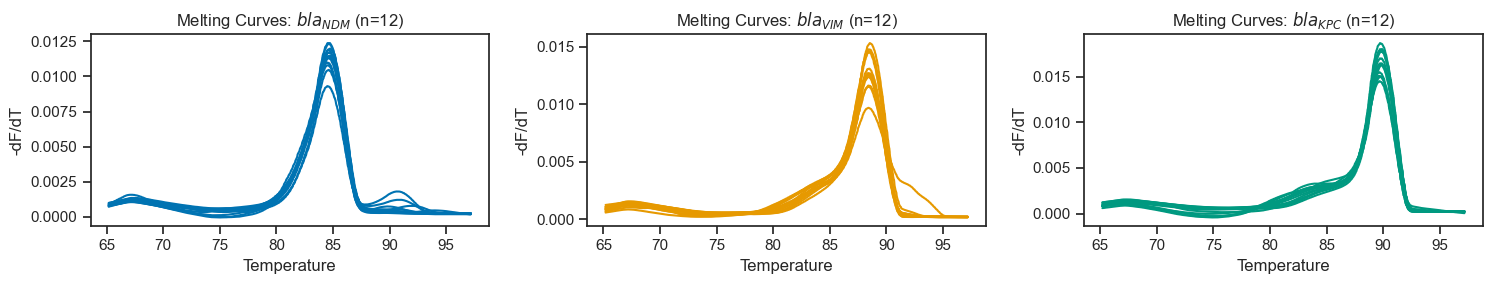

In [6]:
targets = ['NDM', 'VIM', 'KPC']
names = ['$bla_{NDM}$', '$bla_{VIM}$', '$bla_{KPC}$']
colors = ['C0', 'C1', 'C2']
data = qPCR_pure_melting
data_type = 'MC'
xlabel = 'Temperature'
ylabel = '-dF/dT'
title = 'Melting Curves'

fig, ax = plt.subplots(1, len(targets), dpi=DPI, figsize=(15, 3))
for i, (target, name, color) in enumerate(zip(targets, names, colors)):
    
    utils.plot_curves(ax[i], data, target, name, color, data_type, xlabel, ylabel, title)
    
plt.tight_layout()
plt.show()

## Mixture Amplification Curves

In [7]:
qPCR_mixture = pd.read_csv('Data/qPCR_Dataset_Mixture.csv')
qPCR_mixture.head()

,LoadedPanels,Conc,Scaling,Cycle0,Cycle1,Cycle2,Cycle3,Cycle4,Cycle5,Cycle6,...,Cycle30,Cycle31,Cycle32,Cycle33,Cycle34,Cycle35,Cycle36,Cycle37,Cycle38,Cycle39
0,VIM,10000.0,2.900945,-0.002089,-0.003439,-0.002231,-0.001128,0.000575,0.002630,0.001587,...,1.496290,1.670628,1.829032,1.977622,2.109384,2.236136,2.351676,2.458582,2.549289,2.636999
1,NDM,10000.0,2.527009,0.000870,-0.001441,-0.002054,-0.000358,-0.000997,0.001580,0.000189,...,1.205164,1.426428,1.624628,1.802796,1.957516,2.087962,2.188565,2.266916,2.318940,2.349120
2,KPC,10000.0,3.173092,-0.002342,-0.001462,-0.000844,0.001199,0.000163,0.001006,0.000083,...,1.684664,1.899823,2.090091,2.263908,2.413770,2.550580,2.675556,2.778491,2.875429,2.953253
3,VIM_NDM,10000.0,2.880412,-0.001410,0.000698,-0.000744,-0.000816,0.000029,-0.000504,0.001230,...,1.819224,1.994443,2.151108,2.287434,2.404559,2.500241,2.578461,2.646096,2.699013,2.747796
4,VIM_KPC,10000.0,3.217004,-0.008593,-0.001937,-0.001095,-0.000349,0.003361,0.002100,0.002861,...,1.597483,1.829285,2.033220,2.218376,2.380510,2.528939,2.657375,2.769185,2.870129,2.961783


In [29]:
qPCR_mixture.shape

(42, 43)

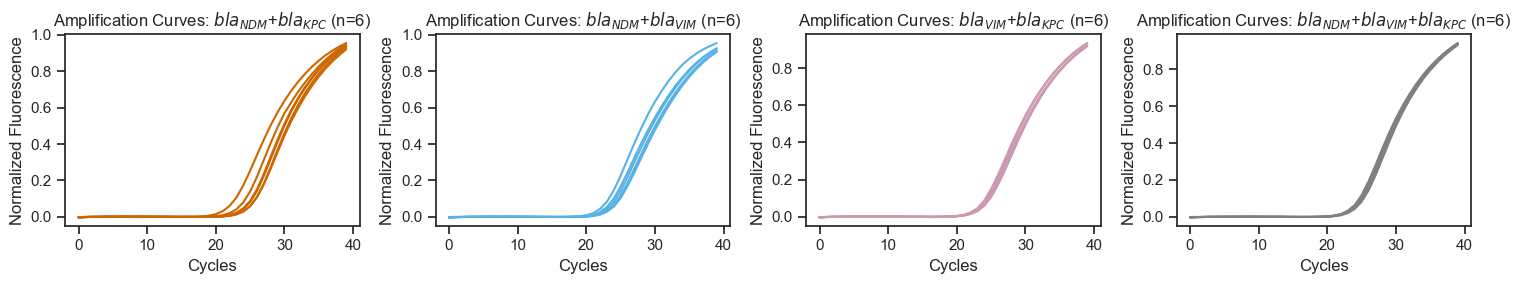

In [8]:
targets = ['NDM_KPC', 
           'VIM_NDM', 
           'VIM_KPC',
           'VIM_NDM_KPC']
names = ['$bla_{NDM}$+$bla_{KPC}$', 
         '$bla_{NDM}$+$bla_{VIM}$', 
         '$bla_{VIM}$+$bla_{KPC}$',
         '$bla_{NDM}$+$bla_{VIM}$+$bla_{KPC}$']
colors = ['C3', 'C4', 'C5', 'C6']
data = utils.normalized(qPCR_mixture)
data_type = 'AC'
xlabel = 'Cycles'
ylabel = 'Normalized Fluorescence'
title = 'Amplification Curves'

fig, ax = plt.subplots(1, len(targets), dpi=DPI, figsize=(15, 3))
for i, (target, name, color) in enumerate(zip(targets, names, colors)):
    
    utils.plot_curves(ax[i], data, target, name, color, data_type, xlabel, ylabel, title)
    
plt.tight_layout()
plt.show()

## Mixture Melting Curves

In [9]:
qPCR_mixture_melting = utils.interpolate_melting(pd.read_csv('Data/qPCR_Meltings_Mixture.csv'))
qPCR_mixture_melting.head()

,LoadedPanels,65.1819,65.1856,65.1907,65.1913,65.1919,65.1925,65.1942,65.2076,65.2202,...,97.117,97.1223,97.1239,97.1246,97.1339,97.1431,97.1458,97.153,97.1542,97.1857
0,VIM,0.001033,0.001034,0.001034,0.001035,0.001036,0.001037,0.001038,0.001039,0.001040,...,0.000435,0.000435,0.000435,0.000435,0.000435,0.000435,0.000435,0.000435,0.000435,0.000435
1,NDM,0.001273,0.001273,0.001274,0.001274,0.001275,0.001276,0.001276,0.001277,0.001278,...,0.000165,0.000165,0.000165,0.000165,0.000165,0.000165,0.000165,0.000165,0.000165,0.000165
2,KPC,0.001206,0.001207,0.001208,0.001209,0.001210,0.001211,0.001213,0.001214,0.001215,...,0.000228,0.000228,0.000228,0.000228,0.000228,0.000228,0.000228,0.000228,0.000228,0.000228
3,VIM_NDM,0.001123,0.001125,0.001126,0.001127,0.001128,0.001129,0.001131,0.001132,0.001133,...,0.000161,0.000161,0.000161,0.000161,0.000161,0.000161,0.000161,0.000161,0.000161,0.000161
4,VIM_KPC,0.001196,0.001197,0.001198,0.001199,0.001200,0.001201,0.001202,0.001203,0.001204,...,0.000240,0.000240,0.000240,0.000240,0.000240,0.000240,0.000240,0.000240,0.000240,0.000240


In [27]:
qPCR_mixture_melting.shape

(42, 6616)

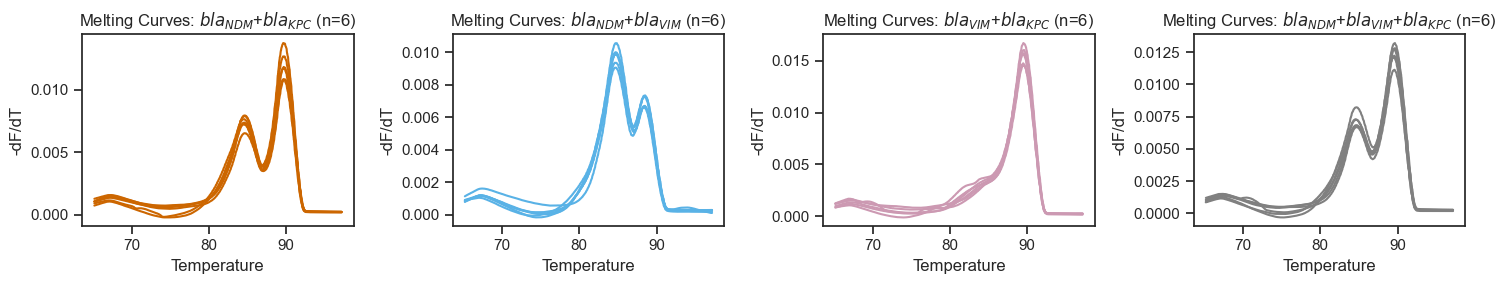

In [10]:
targets = ['NDM_KPC', 
           'VIM_NDM', 
           'VIM_KPC',
           'VIM_NDM_KPC']
names = ['$bla_{NDM}$+$bla_{KPC}$', 
         '$bla_{NDM}$+$bla_{VIM}$', 
         '$bla_{VIM}$+$bla_{KPC}$',
         '$bla_{NDM}$+$bla_{VIM}$+$bla_{KPC}$']
colors = ['C3', 'C4', 'C5', 'C6']
data = qPCR_mixture_melting
data_type = 'MC'
xlabel = 'Temperature'
ylabel = '-dF/dT'
title = 'Melting Curves'

fig, ax = plt.subplots(1, len(targets), dpi=DPI, figsize=(15, 3))
for i, (target, name, color) in enumerate(zip(targets, names, colors)):
    
    utils.plot_curves(ax[i], data, target, name, color, data_type, xlabel, ylabel, title)
    
plt.tight_layout()
plt.show()